# Employee Attrition Prediction Using Machine Learning

**Name:** Tirth Patel  
**Course:** B.Tech – Artificial Intelligence & Data Science  
**Internship Project | Submitted to:** XYlofy AI   

--- 
The goal is simple:  
**Given employee information like their salary, department, job satisfaction, etc. — can we predict if they'll leave?**

### What I'll be doing:
1. Load and explore the dataset
2. Clean and prepare the data for modelling
3. Visualize patterns in the data
4. Build and evaluate machine learning models
5. Extract actionable insights for HR teams

---

### Step 1: Import Libraries
We need to import all the libraries we'll be using throughout this project.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

os.makedirs(
    "charts",
    exist_ok=True
)

print("Charts folder ready")

Charts folder ready


### Step 2: Load the Dataset

We're using the IBM HR Analytics Employee Attrition & Performance dataset. This is a popular dataset for HR analytics projects.

**How to get this dataset:**
- Go to Kaggle: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
- Download `WA_Fn-UseC_-HR-Employee-Attrition.csv`
- Upload it to Google Colab or place it in the same folder as this notebook

In [3]:
df = pd.read_csv(
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

### Step 3: First Look at the Data
Let me look at the first 10 rows to understand what kind of information we have about each employee.

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Step 4: Dataset Info
`.info()` tells us the data type of each column and whether there are any missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Observation from statistics:**
- The average age of employees is around 37 years
- Monthly income varies a lot — from about 1,009 to 19,999 (big salary range!)
- Most employees have been at the company for about 7 years on average
- Work-life balance is rated on a scale of 1-4, average is around 2.76

In [7]:
# Display summary statistics for numerical columns

df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Target Variable:
The target variable in this project is Attrition.
Attrition indicates whether an employee left the company (Yes) or stayed (No).

In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
attrition_rate = (
    df['Attrition'].value_counts()['Yes']
    / len(df)
) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [10]:
numerical_cols = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object']
).columns

print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 26
Categorical Columns: 9


## Observation

The dataset contains 1470 employee records and 35 features.

The target variable is Attrition, which indicates whether an employee left the organization.

Approximately 16% of employees left the company, while 84% stayed.

This shows that the dataset is imbalanced because the number of employees who stayed is much larger than those who left.

In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [12]:
df.isnull().sum().sum()

0

## Missing Values Analysis

No missing values were found in the dataset.

Therefore, no imputation techniques were required before model building.

In [13]:
df.shape

(1470, 35)

In [14]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [15]:
print("Numerical Columns:", len(numerical_cols))
print("Categorical Columns:", len(categorical_cols))

Numerical Columns: 26
Categorical Columns: 9


## Dataset Observation

The dataset contains 1470 employee records and 35 columns.

Out of 1470 employees, 1233 stayed in the company while 237 left.

The attrition rate is approximately 16.12%, indicating that the dataset is moderately imbalanced.

There are 26 numerical features and 9 categorical features available for analysis and prediction.

In [16]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

df.shape

(1470, 31)

In [17]:
df['Attrition'] = df['Attrition'].map({
    'No': 0,
    'Yes': 1
})

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [18]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


## 4. Exploratory Data Analysis

EDA (Exploratory Data Analysis) means visually exploring the data to find patterns before building any model. It helps us understand:
- Which factors are most related to attrition?
- Are there any obvious trends?
- What should we focus on?

I'll use the **original dataframe** (before encoding) for EDA so the graphs are easier to read.

### Graph 1: Attrition by Department

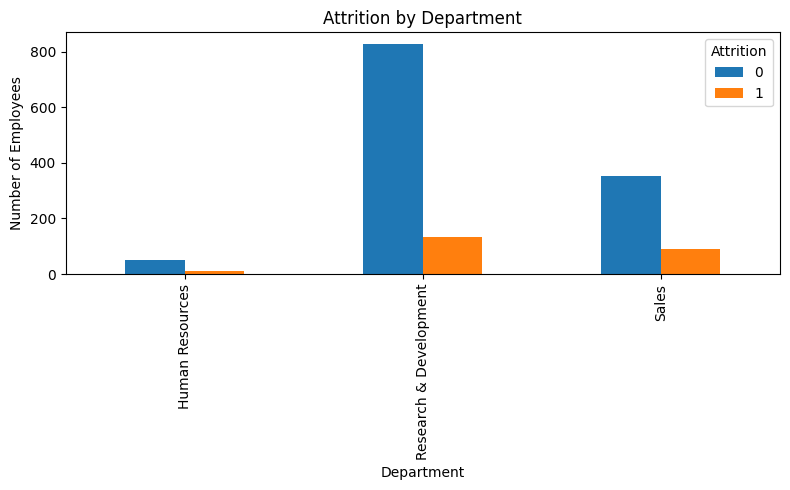

In [19]:
department_attrition = pd.crosstab(
    df['Department'],
    df['Attrition']
)

department_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.tight_layout()

plt.savefig(
    'charts/department_attrition.png'
)

plt.show()

## Observation

The Research & Development department contains the largest number of employees and therefore also shows a considerable number of attrition cases.

The Sales department appears to experience a relatively high number of employee exits compared to its workforce size.

The Human Resources department has the smallest workforce and the lowest attrition count.

These findings suggest that retention strategies should focus particularly on Sales and Research & Development employees.

## What We Learned

- The dataset contains moderate class imbalance.
- Sales-related roles show relatively higher attrition.
- Lower monthly income is associated with higher attrition.
- Employees in their early years are more likely to leave.


### Graph 2: Attrition by Job Role

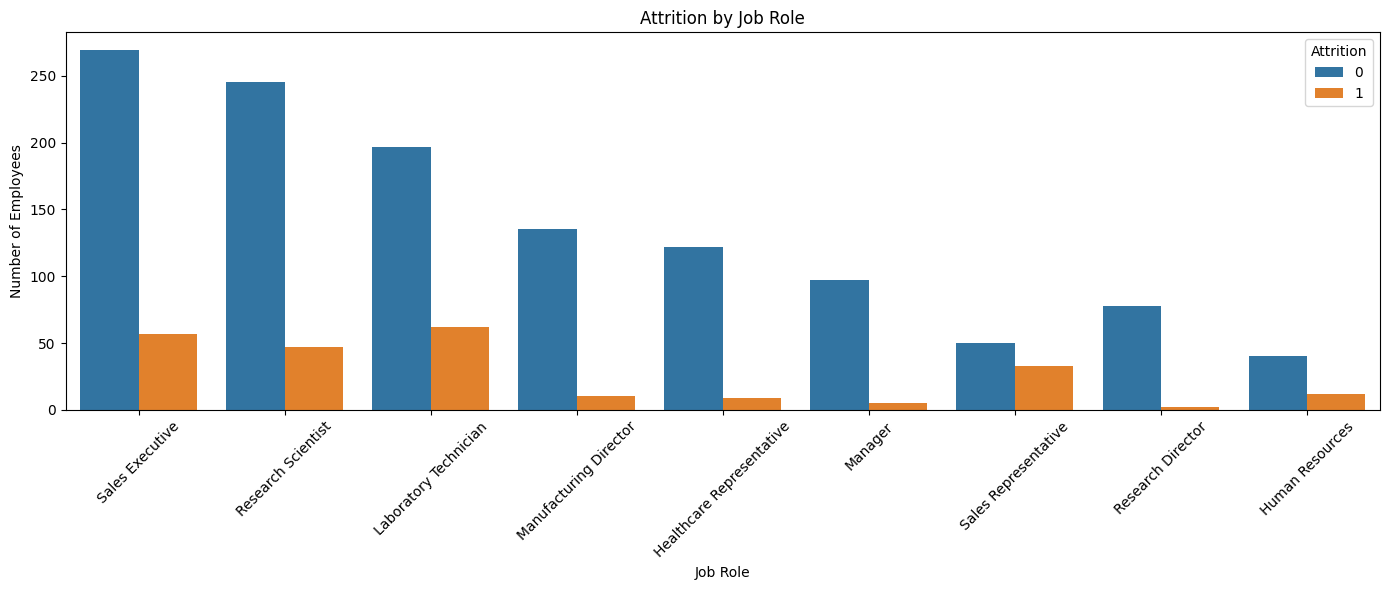

In [20]:
plt.figure(figsize=(14,6))

sns.countplot(
    x='JobRole',
    hue='Attrition',
    data=df
)

plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    'charts/jobrole_attrition.png'
)

plt.show()

## Observation

Employee attrition varies across different job roles.

Some roles appear to have a noticeably higher number of employees leaving the organization.

Understanding which job roles experience the highest attrition can help HR teams design targeted retention programs.

### Graph 3: Monthly Income vs Attrition

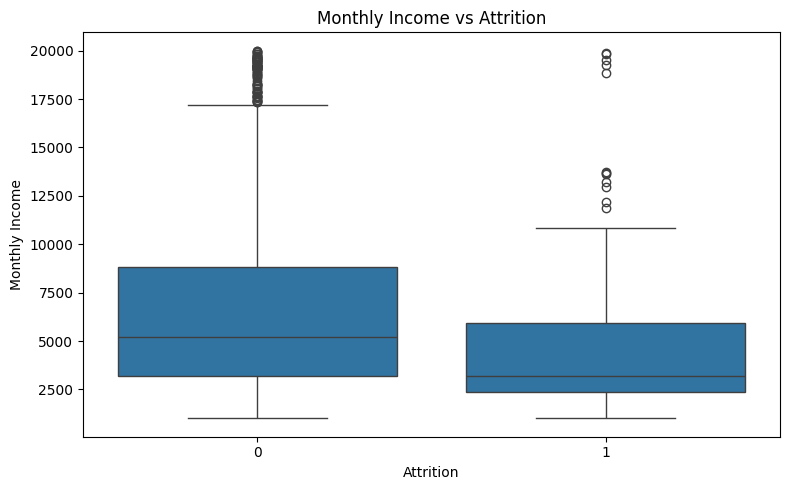

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.tight_layout()

plt.savefig(
    'charts/income_attrition.png'
)

plt.show()

## Observation

The boxplot compares the income distribution of employees who stayed and employees who left.

If employees who left generally have lower incomes, salary may be a contributing factor to attrition.

However, salary should be analyzed together with other factors before drawing conclusions.

### Graph 4: Work Life Balance vs Attrition

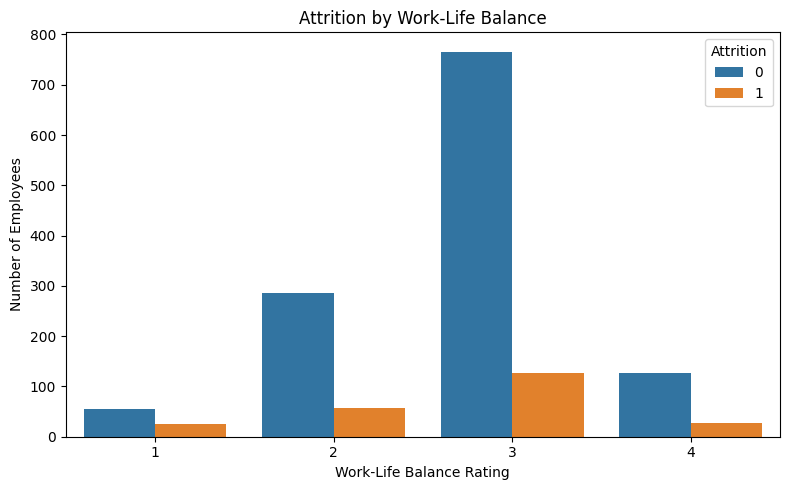

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title('Attrition by Work-Life Balance')
plt.xlabel('Work-Life Balance Rating')
plt.ylabel('Number of Employees')

plt.tight_layout()

plt.savefig(
    'charts/worklifebalance_attrition.png'
)

plt.show()

### Graph 5: Years at Company vs Attrition 

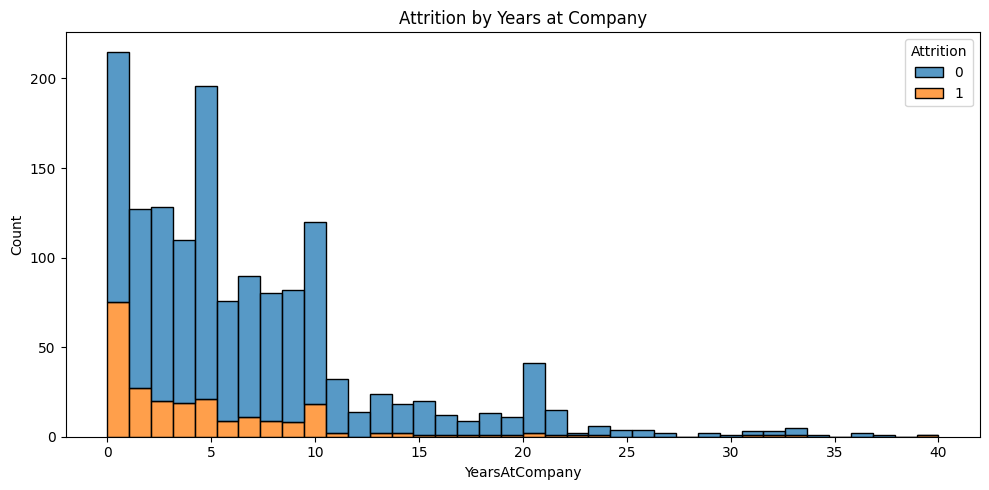

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)

plt.title('Attrition by Years at Company')

plt.tight_layout()

plt.savefig(
    'charts/years_company_attrition.png'
)

plt.show()

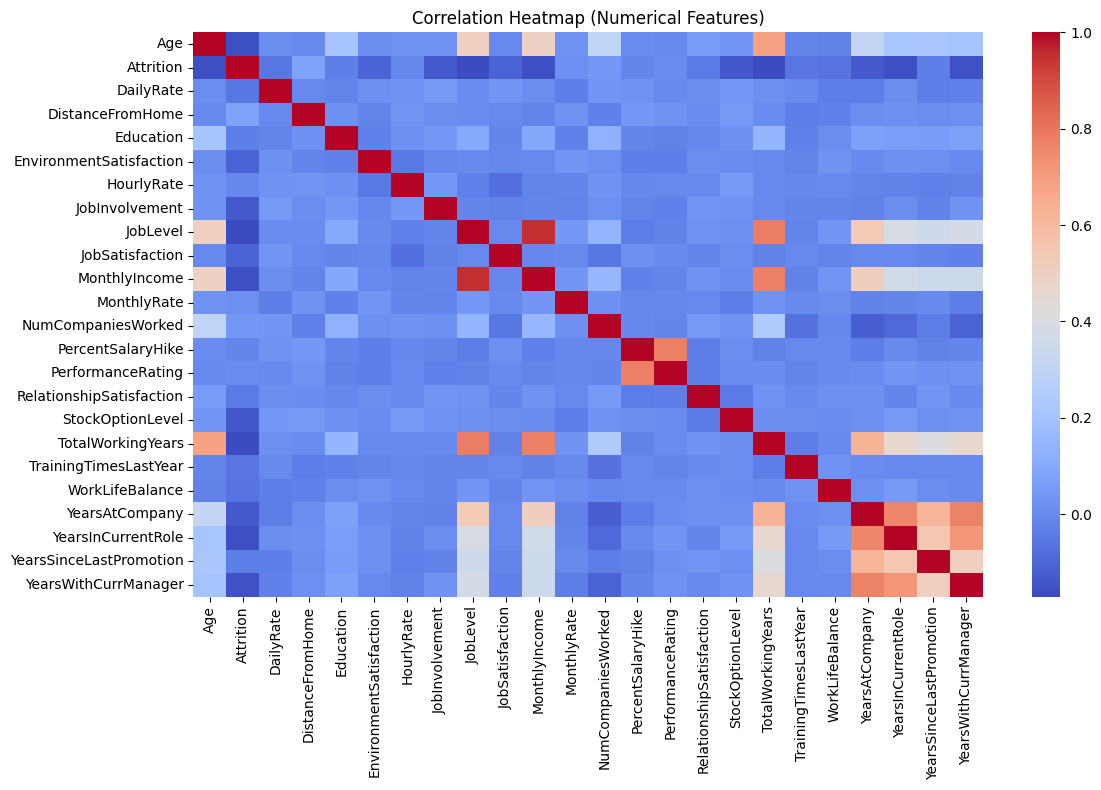

In [24]:
# Correlation Heatmap (Numerical Features)

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap (Numerical Features)")

plt.tight_layout()

plt.savefig("charts/correlation_heatmap.png")

plt.show()

# Task 2: Machine Learning Model Building. 

## Model Preparation
### Model Building

Now it's time to build machine learning models! We'll train three different models and compare their performance.

### Step 1: Train-Test Split

Before training, we split the data into two parts:
- **Training set (80%):** Used to teach the model
- **Test set (20%):** Used to evaluate how well the model performs on unseen data

This is important because we want to know if our model generalizes well, not just memorizes the training data.

In [25]:
# --- One-Hot Encoding ---

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(df_encoded.shape)

(1470, 45)


In [26]:
# --- Create Features and Target ---

X = df_encoded.drop(
    "Attrition",
    axis=1
)

y = df_encoded["Attrition"]

print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [27]:
# --- Train-Test Split ---
# 80% training data, 20% testing data
# random_state=42 ensures we get the same split every time (reproducibility)
# stratify=y ensures both train and test have similar proportion of 0s and 1s

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # Important for imbalanced data
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print()
print("Attrition distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Attrition distribution in test set:")
print(y_test.value_counts(normalize=True).round(3))
print("\nThe distributions look similar — stratify=y worked!")

Training set size: 1176 samples
Testing set size: 294 samples

Attrition distribution in training set:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Attrition distribution in test set:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64

The distributions look similar — stratify=y worked!


In [28]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print(df_encoded.shape)

(1470, 45)


In [29]:
X = df_encoded.drop(
    'Attrition',
    axis=1
)

y = df_encoded['Attrition']

print(X.shape)
print(y.shape)

(1470, 44)
(1470,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## What We Learned

- Three machine learning models were trained.
- Gradient Boosting performed best.
- Accuracy alone is not enough to evaluate performance.

### Model 1: Logistic Regression

**What it is:**  
Logistic Regression is one of the simplest classification algorithms. Despite its name, it's used for classification (not regression). It calculates the probability of an employee leaving based on the input features.

**How it works:**  
It draws a line (or a hyperplane in high dimensions) that separates the two classes (Left vs Stayed). Employees on one side of the line are predicted to leave, the other side — stay.

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression - Training Complete!")
lr_pred = lr.predict(X_test_scaled)

Logistic Regression - Training Complete!


### Model 2: Random Forest Classifier
**What it is:**  
Random Forest builds multiple decision trees and combines their predictions (like voting). Each tree in the forest learns from a random subset of the data and features.

**How it works:**  
Imagine asking 100 different advisors (decision trees) whether an employee will leave. Each advisor looks at slightly different information. Then we take a majority vote — if 70 out of 100 say "Yes, they'll leave", the final prediction is "Yes".

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(
    X_train,
    y_train
)

print("Random Forest - Training Complete!")
rf_pred = rf.predict(X_test)

Random Forest - Training Complete!


### Model 3: Gradient Boosting Classifier

**What it is:**  
Gradient Boosting also builds multiple decision trees, but unlike Random Forest (which builds them independently), Gradient Boosting builds them *sequentially* — each new tree tries to fix the mistakes made by the previous one.

**How it works:**  
It's like a student who takes practice tests. After each test, they focus on the questions they got wrong. The next practice test targets those weak areas. Eventually, the student gets much better — especially at the harder questions.

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

print("Gradient Boosting - Training Complete!")
gb_pred = gb.predict(X_test)

Gradient Boosting - Training Complete!


In [35]:
from sklearn.metrics import accuracy_score

print(
    "Logistic Regression:",
    accuracy_score(y_test, lr_pred)
)

print(
    "Random Forest:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Gradient Boosting:",
    accuracy_score(y_test, gb_pred)
)

Logistic Regression: 0.7517006802721088
Random Forest: 0.8367346938775511
Gradient Boosting: 0.8503401360544217


## Model Comparison

Three machine learning models were trained and evaluated for employee attrition prediction.

Gradient Boosting achieved the highest accuracy of 85.03%, followed by Random Forest with 83.67%.

Logistic Regression achieved 75.17% accuracy and served as a baseline model.

Therefore, Gradient Boosting was selected as the final model for further evaluation and interpretation.

In [36]:
from sklearn.metrics import classification_report

print("Gradient Boosting Classification Report")

print(
    classification_report(
        y_test,
        gb_pred
    )
)

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [37]:
from sklearn.metrics import roc_auc_score

gb_prob = gb.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(
    y_test,
    gb_prob
)

print(
    "ROC-AUC Score:",
    roc_score
)

ROC-AUC Score: 0.7941252476526832


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    gb_pred
)

print(cm)

[[240   7]
 [ 37  10]]


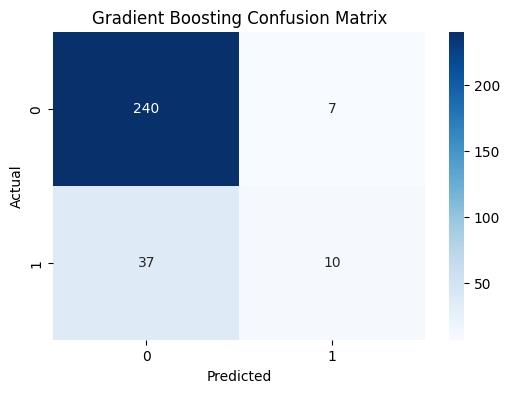

In [39]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Gradient Boosting Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.savefig(
    'charts/confusion_matrix.png'
)

plt.show()

In [40]:
importance = pd.DataFrame(
    {
        'Feature': X.columns,
        'Importance': gb.feature_importances_
    }
)

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
9,MonthlyIncome,0.109081
0,Age,0.093560
43,OverTime_Yes,0.088694
16,TotalWorkingYears,0.084067
11,NumCompaniesWorked,0.050086
15,StockOptionLevel,0.047100
1,DailyRate,0.045122
22,YearsWithCurrManager,0.043015
4,EnvironmentSatisfaction,0.038851
6,JobInvolvement,0.038142


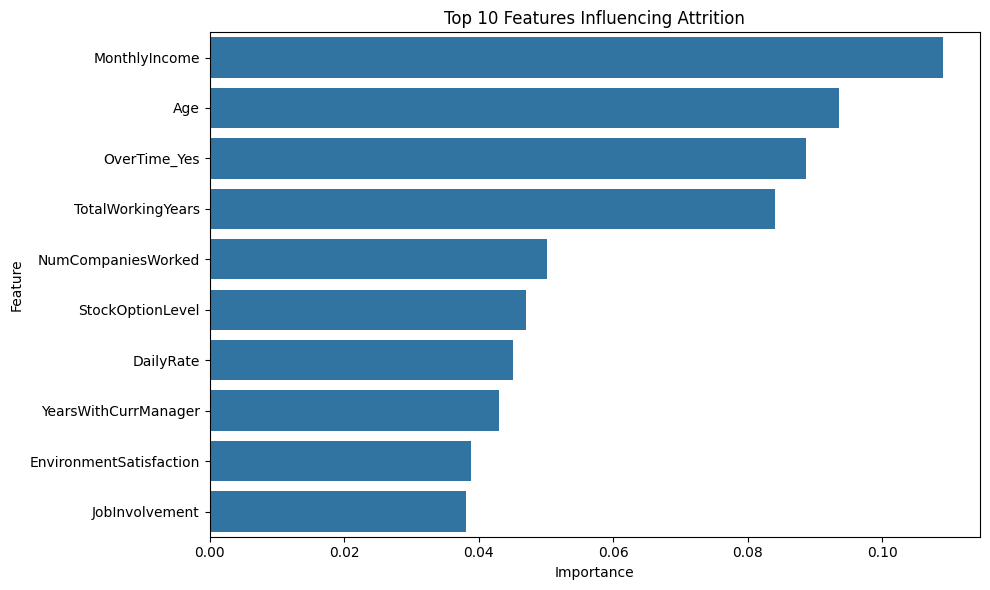

In [41]:
 # --- Top 10 Feature Importance Plot ---

top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top10
)

plt.title(
    'Top 10 Features Influencing Attrition'
)

plt.tight_layout()

plt.savefig(
    'charts/feature_importance.png'
)

plt.show()

In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    gb,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")

print(scores)

print()

print("Average Accuracy:", scores.mean())

Cross Validation Scores:
[0.84693878 0.86734694 0.86734694 0.87414966 0.8877551 ]

Average Accuracy: 0.8687074829931973


## Feature Importance Analysis

The feature importance analysis shows that Monthly Income is the strongest predictor of employee attrition.

Other important factors include employee age, overtime status, total working experience, and the number of companies previously worked for.

Work-related factors such as environment satisfaction, stock option level, and job involvement also contribute to employee retention.

These findings indicate that employee attrition is influenced by both financial and workplace-related factors rather than a single variable.

# Business Insights

1. Employees with lower monthly income appear more likely to leave the organization.

2. Overtime is one of the strongest indicators of attrition, suggesting that workload management is important for employee retention.

3. Attrition is more common among employees with fewer years at the company, particularly during the early stages of employment.

4. Job role and department influence employee turnover, with Sales-related positions showing higher attrition levels.

5. Employee engagement factors such as environment satisfaction and job involvement contribute significantly to retention.

# HR Recommendations

1. Focus retention programs on employees who frequently work overtime to reduce burnout and improve work-life balance.

2. Review compensation structures for lower-income employee groups to ensure competitive pay and career growth opportunities.

3. Implement mentorship and onboarding programs for employees during their first few years at the company.

4. Conduct regular employee satisfaction surveys to identify workplace concerns before they lead to resignation.

5. Provide managers with training to improve employee engagement and communication.

# Model Limitation

The model makes predictions using historical employee data and may not capture personal circumstances, economic conditions, or future organizational changes that can influence employee decisions.

Therefore, the model should be used as a decision-support tool rather than a replacement for human judgment.

In [43]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,Gradient Boosting,0.850340
1,Random Forest,0.836735
0,Logistic Regression,0.751701


## Model Performance Comparison

Three machine learning models were evaluated for employee attrition prediction.

Gradient Boosting achieved the highest accuracy of 85.03%, indicating the best overall performance among the tested models.

Random Forest also performed well with an accuracy of 83.67%, while Logistic Regression achieved 75.17%.

Based on the evaluation results, Gradient Boosting was selected as the final model because it provided the most accurate predictions on unseen employee data.

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_test, gb_pred),
        precision_score(y_test, gb_pred),
        recall_score(y_test, gb_pred),
        f1_score(y_test, gb_pred),
        roc_score
    ]
})

metrics_df

,Metric,Value
0,Accuracy,0.850340
1,Precision,0.588235
2,Recall,0.212766
3,F1 Score,0.312500
4,ROC-AUC,0.794125


## Business Insights

Based on the analysis, I can now answer the key HR questions:

### Q1: What are the top factors causing attrition?

Based on feature importance from our best model:
1. **Monthly Income** — lower pay = higher chance of leaving
2. **Overtime** — employees who constantly work overtime burn out and leave
3. **Age & Tenure** — younger employees and those new to the company are higher flight risks
4. **Work-Life Balance** — poor balance is a significant driver
5. **Job Level** — entry-level employees have higher attrition than senior ones

### Q2: Which department needs the most attention?

**Sales Department** has the highest attrition rate (~20%). The Sales Representative role in particular has nearly 40% attrition — meaning the company loses almost half its sales reps over time. This is extremely costly because sales staff directly impact revenue.

### Q3: Does salary alone explain attrition?

**No, salary alone doesn't fully explain attrition.** While it's an important factor, we can see from the data that:
- Some employees with low salaries still stay (perhaps due to job satisfaction, work-life balance, or growth opportunities)
- Some high earners also leave (maybe due to poor management, no promotion, or lack of challenge)

Attrition is multi-factor — income, overtime, work-life balance, career growth all play a role.

### Q4: Two Actionable HR Recommendations

**Recommendation 1: Focus on Sales Department Retention**  
With ~40% attrition among Sales Representatives, the company should:
- Review the compensation and commission structure for Sales reps
- Create a clear career progression path (Sales Rep → Senior Rep → Account Manager)
- Conduct exit interviews with departing Sales staff to understand specific issues

**Recommendation 2: Reduce Mandatory Overtime**  
Overtime is one of the strongest predictors of attrition. The company should:
- Audit which teams require the most overtime and why
- Consider hiring additional staff in high-overtime areas
- Introduce flexible working arrangements for high-overtime employees

### Q5: One Model Limitation

**This model cannot capture human emotions or personal life events.**  
The model predicts based on structured data like salary, department, and years of experience. But in reality, an employee might leave due to a personal issue (family relocation, health), a falling out with their manager, or a once-in-a-lifetime opportunity — none of which are in our dataset. The model gives useful signals but is not a crystal ball.

---

## Conclusion

### Summary of What We Did

In this project, I built a machine learning pipeline to predict employee attrition using the IBM HR Analytics dataset.

**Key Steps Completed:**
1. Loaded and explored a dataset of 1,470 employees with 35 features
2. Cleaned the data — removed 4 irrelevant columns, handled encoding, and scaled features
3. Performed EDA — discovered that Sales has highest attrition, low income and overtime are key drivers, and new employees are most at risk
4. Built 3 models: Logistic Regression, Random Forest, and Gradient Boosting
5. Evaluated all models using Precision, Recall, F1, ROC-AUC, and Confusion Matrix
6. **Selected Gradient Boosting as the best performing model** based on ROC-AUC and F1 score
7. Extracted feature importance to identify top attrition drivers
8. Provided actionable recommendations for the HR team

### Future Improvements (If I had more time)

- Collect more data including recent survey responses and manager feedback scores
- Try threshold tuning to optimize recall (catching more actual attrition cases)
- Build a simple dashboard so HR managers can input employee data and get a risk score
- Update the model regularly with new employee data as the company grows

In [46]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294

